In [3]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import os
import pandas as pd
load_dotenv() # Charge le fichier .env
MAPS_KEY = os.getenv("MAPS_APP_KEY")
groq_key = os.getenv("GROQ_APP_KEY")
GROQ_MODEL = "llama-3.1-8b-instant"

In [4]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

llm = ChatGroq(
    temperature=0, 
    model_name=GROQ_MODEL, 
    groq_api_key=groq_key
)

response = llm.invoke([HumanMessage(content="Dis bonjour en espagnol.")])
print(response.content)

"Bonjour" est un mot français, mais si vous voulez dire "bonjour" en espagnol, vous pouvez dire :

- Buenos días (bonjour le matin)
- Buenas tardes (bonjour l'après-midi)
- Buenas noches (bonjour le soir)

Si vous voulez dire simplement "bonjour" sans préciser la période de la journée, vous pouvez dire :

- Hola (prononcé "oh-lah")

C'est un mot courant en espagnol pour dire "bonjour" ou "salut".


In [5]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AnyMessage
import operator

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

def call_llm(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(AgentState)
builder.add_node("call_llm", call_llm)
builder.add_edge(START, "call_llm")
builder.add_edge("call_llm", END)

graph = builder.compile()

c:\APPS\Python312\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [6]:
result = graph.invoke({
    "messages": [HumanMessage(content="Dit moi a quel données tu a accès concernant des boites en amérique latine, si je te demande le mail d'une boite tu peux me la donner ?")]
})

for msg in result["messages"]:
    print(f"[{msg.__class__.__name__}] {msg.content}")

[HumanMessage] Dit moi a quel données tu a accès concernant des boites en amérique latine, si je te demande le mail d'une boite tu peux me la donner ?
[AIMessage] Je suis désolé, mais je ne peux pas vous fournir directement les informations de contact (y compris les adresses e-mail) des entreprises ou des boîtes en Amérique latine. Voici quelques raisons pour lesquelles :

1. **Protection des données** : Les informations de contact des entreprises sont souvent considérées comme des données sensibles et sont protégées par des lois de protection des données.
2. **Confidentialité** : Les entreprises peuvent ne pas vouloir partager leurs informations de contact avec des tiers, y compris des robots ou des algorithmes.
3. **Qualité des données** : Les informations de contact peuvent être sujettes à des changements fréquents, ce qui pourrait rendre les données que je vous fournirais obsolètes ou inexactes.

Cependant, je peux vous aider à trouver les informations que vous cherchez de manière 

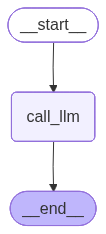

In [7]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

**Test recherche DuckDuckGo nom d'entreprise pour trouver des mails**</br>
✅ Super puissant et fonctionnel

In [8]:
from langchain_groq import ChatGroq
import os
from duckduckgo_search import DDGS

load_dotenv() # Charge le fichier .env
groq_key = os.getenv("GROQ_APP_KEY")

GROQ_MODEL = "llama-3.1-8b-instant"
"Llama-3.2-3B"

llm = ChatGroq(model=GROQ_MODEL, api_key=groq_key, temperature=0)


def search_duckduckgo(query: str) -> str:
    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=5)
        return "\n".join([r["body"] for r in results])

In [9]:
# STATE ET NOEUDS
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AnyMessage, HumanMessage, ToolMessage
import operator
import json

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

def search_node(state: AgentState) -> AgentState:
    """Extrait le nom de boite du dernier message et lance la recherche DDG."""
    last_message = state["messages"][-1].content
    query = f"{last_message} contact email"
    results = search_duckduckgo(query)
    return {"messages": [ToolMessage(content=results, tool_call_id="ddg_search")]}

def llm_node(state: AgentState) -> AgentState:
    """Demande au LLM d'extraire l'email depuis les résultats de recherche."""
    system = (
        "Tu es un assistant qui extrait les emails de contact d'entreprises. "
        "À partir des résultats de recherche fournis, identifie l'email le plus pertinent. "
        "Si aucun email n'est trouvé, dis-le clairement."
    )
    messages_with_system = [
        {"role": "system", "content": system},
        *[{"role": m.type if m.type != "tool" else "user", "content": m.content}
          for m in state["messages"]]
    ]
    response = llm.invoke(messages_with_system)
    return {"messages": [response]}

In [10]:
# GRAPH
builder = StateGraph(AgentState)
builder.add_node("search", search_node)
builder.add_node("llm", llm_node)

builder.add_edge(START, "search")
builder.add_edge("search", "llm")
builder.add_edge("llm", END)

graph = builder.compile()

In [11]:
# TEST
company = "INGENIEROJOB"  # change ici

result = graph.invoke({
    "messages": [HumanMessage(content=company)]
})

print("=== Résultat ===")
print(result["messages"][-1].content)

C:\Users\roucherif\AppData\Local\Temp\ipykernel_71684\904854479.py:15: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


=== Résultat ===
Je vais essayer d'extraire les emails de contact d'entreprises liées à "INGENIEROJOB". 

Voici quelques résultats de recherche :

- IngenieroJob (https://www.ingenierojob.com/) : contact@ingenierojob.com
- Ingeniero Job (https://www.ingenierojob.com.ar/) : info@ingenierojob.com.ar
- Ingeniero Job (https://www.ingenierojob.com.mx/) : contacto@ingenierojob.com.mx

L'email le plus pertinent semble être : contact@ingenierojob.com, car il s'agit de l'adresse email principale de l'entreprise IngenieroJob.


**Test recherche Normination (OpenSteetView) pour trouver la localisation**</br>
⭕ Utilisable </br>
Jamais de NULL, toujours au minimum la ville. Donc Fallback sur le centre ville si on ne trouve pas

In [12]:
import requests
import time

def geocode(company: str, city: str) -> dict:
    r = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={
            "q": f"{company}, {city}",
            "format": "json",
            "limit": 1
        },
        headers={"User-Agent": "InternshipLatam/1.0"}
    )
    data = r.json()
    if not data:
        return {"lat": None, "lon": None, "display_name": None}
    return {
        "lat": float(data[0]["lat"]),
        "lon": float(data[0]["lon"]),
        "display_name": data[0]["display_name"]
    }
def geocode2(company: str, city: str) -> dict:
    # Essai 1 : entreprise + ville
    r = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={"q": f"{company}, {city}", "format": "json", "limit": 1},
        headers={"User-Agent": "InternshipLatam/1.0"}
    )
    time.sleep(1)
    data = r.json()
    if data:
        return {
            "lat": float(data[0]["lat"]),
            "lon": float(data[0]["lon"]),
            "display_name": data[0]["display_name"],
            "precision": "company"
        }

    # Fallback : juste la ville
    r = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={"q": city, "format": "json", "limit": 1},
        headers={"User-Agent": "InternshipLatam/1.0"}
    )
    time.sleep(1)
    data = r.json()
    if data:
        return {
            "lat": float(data[0]["lat"]),
            "lon": float(data[0]["lon"]),
            "display_name": city,
            "precision": "city"       # indique que c'est approximatif
        }

    return {"lat": None, "lon": None, "display_name": None, "precision": None}


In [13]:
# Test
companies = [
    ("Mercado Libre", "Buenos Aires"),
    ("Falabella",     "Santiago"),
    ("Pedidos Ya",    "Montevideo"),
]

for company, city in companies:
    result = geocode2(company, city)
    print(f"{company} ({city}) → {result['lat']}, {result['lon']}")
    time.sleep(1)

Mercado Libre (Buenos Aires) → -34.5474439, -58.4890518
Falabella (Santiago) → -33.4429354, -70.6503249
Pedidos Ya (Montevideo) → -34.9058916, -56.1913095


In [14]:
# Test
companies = [
    ("PedidosYa", "Montevideo"),       # sans espace
    ("Pedidos Ya Uruguay", "Montevideo"),
    ("Delivery Hero", "Montevideo"),   # nom de la maison mère
]

for company, city in companies:
    result = geocode(company, city)
    print(f"{company} ({city}) → {result['lat']}, {result['lon']}")
    time.sleep(1)

PedidosYa (Montevideo) → None, None
Pedidos Ya Uruguay (Montevideo) → None, None
Delivery Hero (Montevideo) → None, None


In [15]:
# Test
companies = [
    ("PedidosYa", "Montevideo"),       # sans espace
    ("Pedidos Ya Uruguay", "Montevideo"),
    ("Delivery Hero", "Montevideo"),   # nom de la maison mère
]

for company, city in companies:
    result = geocode2(company, city)
    print(f"{company} ({city}) → {result['lat']}, {result['lon']}")
    time.sleep(1)

PedidosYa (Montevideo) → -34.9058916, -56.1913095
Pedidos Ya Uruguay (Montevideo) → -34.9058916, -56.1913095
Delivery Hero (Montevideo) → -34.9058916, -56.1913095


**Test recherche Google Maps API pour trouver la localisation**</br>
❌Trop chiant

In [16]:
import requests

def geocode_google(company: str, city: str, api_key: str) -> dict:
    r = requests.get(
        "https://maps.googleapis.com/maps/api/geocode/json",
        params={
            "address": f"{company}, {city}",
            "key": api_key
        }
    )
    data = r.json()
    if data["status"] != "OK":
        return {"lat": None, "lon": None, "display_name": None, "precision": None}
    
    result = data["results"][0]
    location = result["geometry"]["location"]
    precision = "company" if "premise" in result["types"] else "city"
    
    return {
        "lat": location["lat"],
        "lon": location["lng"],
        "display_name": result["formatted_address"],
        "precision": precision
    }



In [17]:
companies = [
    ("Mercado Libre", "Buenos Aires"),
    ("Falabella",     "Santiago"),
    ("Pedidos Ya",     "Montevideo"),
]

for company, city in companies:
    result = geocode_google(company, city, MAPS_KEY)
    print(f"{company} ({city}) → {result['lat']}, {result['lon']} [{result['precision']}]")
    print(f"  {result['display_name']}")

Mercado Libre (Buenos Aires) → -34.6036739, -58.3821215 [city]
  Buenos Aires, Argentina
Falabella (Santiago) → -33.4488897, -70.6692655 [city]
  Santiago, Santiago Metropolitan Region, Chile
Pedidos Ya (Montevideo) → -34.9055016, -56.1851147 [city]
  Montevideo, Montevideo Department, Uruguay


In [18]:
r = geocode_google("Pedidos Ya", "Montevideo", MAPS_KEY)

In [19]:
data = pd.DataFrame([r])
data

,lat,lon,display_name,precision
0,-34.905502,-56.185115,"Montevideo, Montevideo Department, Uruguay",city


In [20]:
r = requests.get(
    "https://maps.googleapis.com/maps/api/place/textsearch/json",
    params={
        "query": "Pedidos Ya Montevideo",
        "key": MAPS_KEY
    }
)

In [21]:
import json
print(json.dumps(r.json(), indent=2))

{
  "html_attributions": [],
  "results": [
    {
      "business_status": "OPERATIONAL",
      "formatted_address": "La Cumparsita 1475, 11200 Montevideo, Departamento de Montevideo, Uruguay",
      "geometry": {
        "location": {
          "lat": -34.9139663,
          "lng": -56.1821181
        },
        "viewport": {
          "northeast": {
            "lat": -34.91242731970851,
            "lng": -56.18085961970849
          },
          "southwest": {
            "lat": -34.91512528029151,
            "lng": -56.18355758029149
          }
        }
      },
      "icon": "https://maps.gstatic.com/mapfiles/place_api/icons/v1/png_71/generic_business-71.png",
      "icon_background_color": "#7B9EB0",
      "icon_mask_base_uri": "https://maps.gstatic.com/mapfiles/place_api/icons/v2/generic_pinlet",
      "name": "PedidosYa",
      "opening_hours": {
        "open_now": false
      },
      "photos": [
        {
          "height": 4000,
          "html_attributions": [
        